<a href="https://colab.research.google.com/github/satyaungarala/codesoft/blob/main/task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files

uploaded = files.upload()

Saving movies_data.csv to movies_data (4).csv


In [6]:
import pandas as pd

data = pd.read_csv(
    "movies_data (4).csv",
    encoding='latin1'
)

print(data.head())

                                 Name  Year  Duration  \
0  #Gadhvi (He thought he was Gandhi)  2019       109   
1                             #Yaaram  2019       110   
2                ...Aur Pyaar Ho Gaya  1997       147   
3                           ...Yahaan  2005       142   
4                  ?: A Question Mark  2012        82   

                       Genre  Rating  Votes        Director          Actor 1  \
0                      Drama     7.0      8   Gaurav Bakshi     Rasika Dugal   
1            Comedy, Romance     4.4     35      Ovais Khan          Prateik   
2     Comedy, Drama, Musical     4.7    827    Rahul Rawail       Bobby Deol   
3        Drama, Romance, War     7.4   1086  Shoojit Sircar  Jimmy Sheirgill   
4  Horror, Mystery, Thriller     5.6    326   Allyson Patel        Yash Dave   

                  Actor 2          Actor 3  
0          Vivek Ghamande    Arvind Jangid  
1              Ishita Raj  Siddhant Kapoor  
2  Aishwarya Rai Bachchan    Shammi Kapoo

Saving movies_data (1) (1).csv to movies_data (1) (1) (1).csv
FIRST 5 ROWS
                                 Name  Year  Duration  \
0  #Gadhvi (He thought he was Gandhi)  2019       109   
1                             #Yaaram  2019       110   
2                ...Aur Pyaar Ho Gaya  1997       147   
3                           ...Yahaan  2005       142   
4                  ?: A Question Mark  2012        82   

                       Genre  Rating  Votes        Director          Actor 1  \
0                      Drama     7.0      8   Gaurav Bakshi     Rasika Dugal   
1            Comedy, Romance     4.4     35      Ovais Khan          Prateik   
2     Comedy, Drama, Musical     4.7    827    Rahul Rawail       Bobby Deol   
3        Drama, Romance, War     7.4   1086  Shoojit Sircar  Jimmy Sheirgill   
4  Horror, Mystery, Thriller     5.6    326   Allyson Patel        Yash Dave   

                  Actor 2          Actor 3  
0          Vivek Ghamande    Arvind Jangid  
1          

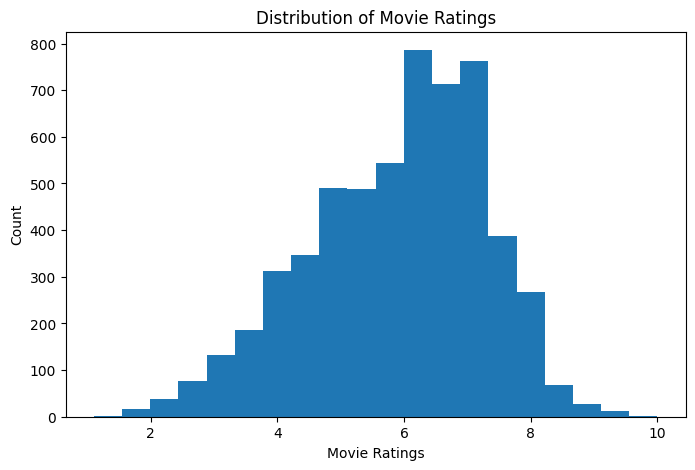


MODEL TRAINING STARTED...

MODEL TRAINING COMPLETED!

MODEL PERFORMANCE
Mean Absolute Error : 0.98
Mean Squared Error  : 1.61
Root Mean Squared Error : 1.27
R2 Score : 0.13


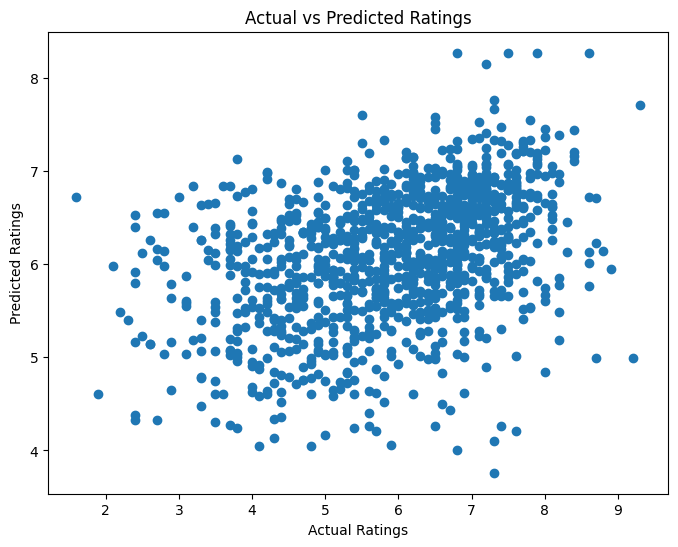

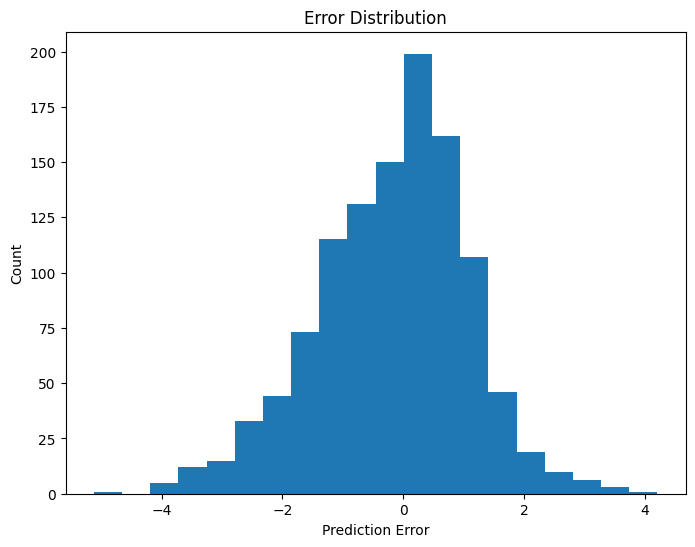


SAMPLE MOVIE PREDICTION
Predicted Movie Rating : 5.62

PROJECT COMPLETED SUCCESSFULLY!


In [8]:
from google.colab import files

uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


data = pd.read_csv(
    "movies_data (4).csv",
    encoding='latin1'
)



print("FIRST 5 ROWS")
print(data.head())

print("\nDATASET SHAPE")
print(data.shape)

print("\nCOLUMN NAMES")
print(data.columns)


data = data[['Genre', 'Director', 'Actor 1', 'Rating']]

data = data.dropna(subset=['Rating'])

data['Genre'] = data['Genre'].fillna('Unknown')
data['Director'] = data['Director'].fillna('Unknown')
data['Actor 1'] = data['Actor 1'].fillna('Unknown')

data['Rating'] = data['Rating'].astype(float)


plt.figure(figsize=(8,5))

plt.hist(data['Rating'], bins=20)

plt.xlabel("Movie Ratings")
plt.ylabel("Count")
plt.title("Distribution of Movie Ratings")

plt.show()


X = data[['Genre', 'Director', 'Actor 1']]
y = data['Rating']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ('genre', TfidfVectorizer(), 'Genre'),
        ('director', TfidfVectorizer(), 'Director'),
        ('actor', TfidfVectorizer(), 'Actor 1')
    ]
)


model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])


print("\nMODEL TRAINING STARTED...\n")

pipeline.fit(X_train, y_train)

print("MODEL TRAINING COMPLETED!")


y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n===================================")
print("MODEL PERFORMANCE")
print("===================================")

print("Mean Absolute Error :", round(mae, 2))
print("Mean Squared Error  :", round(mse, 2))
print("Root Mean Squared Error :", round(rmse, 2))
print("R2 Score :", round(r2, 2))


plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")

plt.title("Actual vs Predicted Ratings")

plt.show()

errors = y_test - y_pred

plt.figure(figsize=(8,6))

plt.hist(errors, bins=20)

plt.xlabel("Prediction Error")
plt.ylabel("Count")

plt.title("Error Distribution")

plt.show()


sample_movie = pd.DataFrame({
    'Genre': ['Action'],
    'Director': ['Rajkumar Hirani'],
    'Actor 1': ['Aamir Khan']
})

predicted_rating = pipeline.predict(sample_movie)

print("\n===================================")
print("SAMPLE MOVIE PREDICTION")
print("===================================")

print("Predicted Movie Rating :", round(predicted_rating[0], 2))


print("\nPROJECT COMPLETED SUCCESSFULLY!")

TOP 10 GENRES

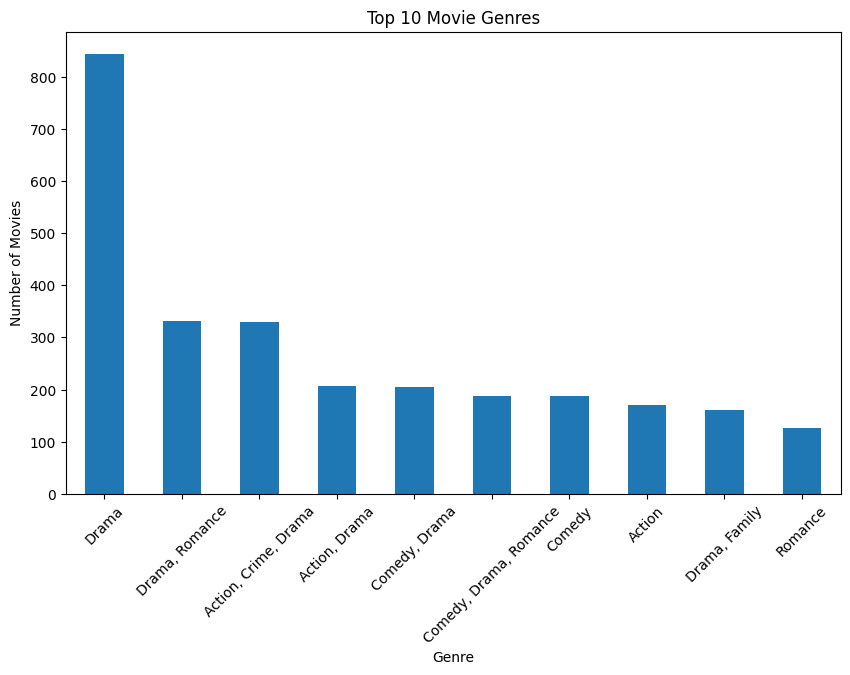

In [9]:


top_genres = data['Genre'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_genres.plot(kind='bar')

plt.xlabel("Genre")
plt.ylabel("Number of Movies")

plt.title("Top 10 Movie Genres")

plt.xticks(rotation=45)

plt.show()

TOP 10 DIRECTORS

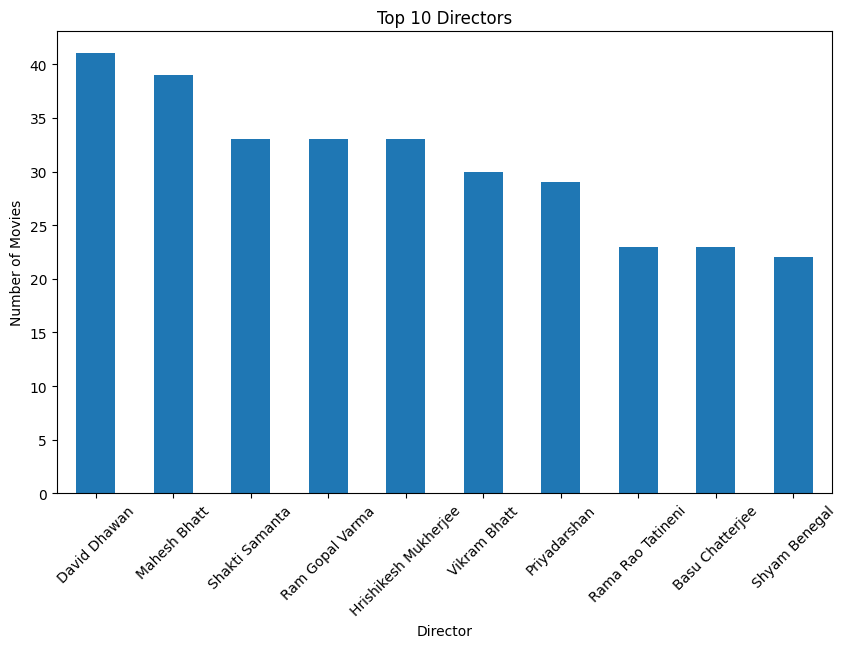

In [10]:

top_directors = data['Director'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_directors.plot(kind='bar')

plt.xlabel("Director")
plt.ylabel("Number of Movies")

plt.title("Top 10 Directors")

plt.xticks(rotation=45)

plt.show()

TOP 10 ACTORS

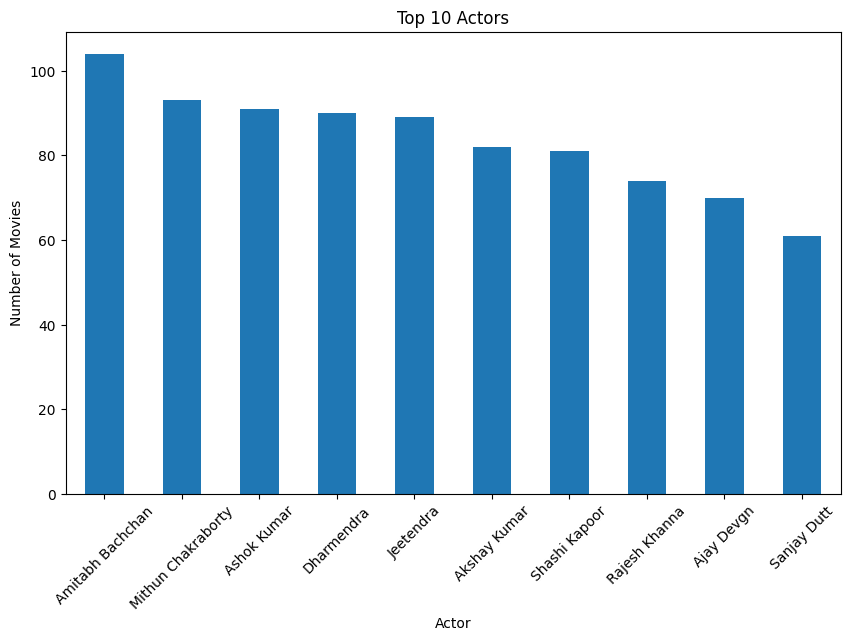

In [11]:


top_actors = data['Actor 1'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_actors.plot(kind='bar')

plt.xlabel("Actor")
plt.ylabel("Number of Movies")

plt.title("Top 10 Actors")

plt.xticks(rotation=45)

plt.show()



PREDICTED RATINGS DISTRIBUTION

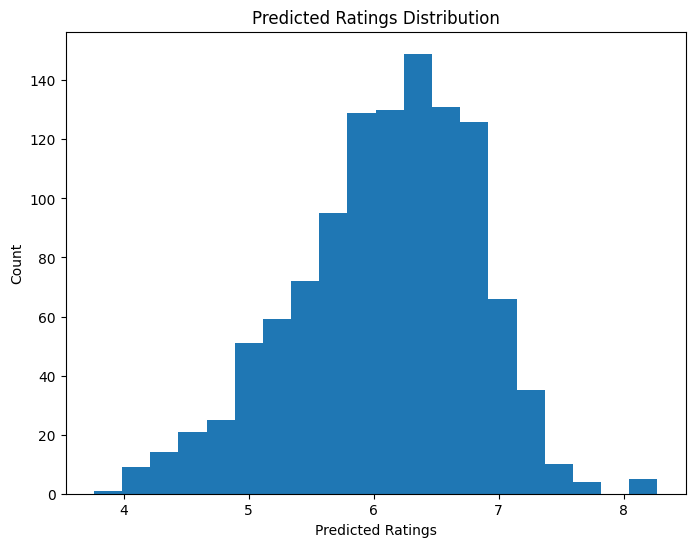

In [12]:


plt.figure(figsize=(8,6))

plt.hist(y_pred, bins=20)

plt.xlabel("Predicted Ratings")
plt.ylabel("Count")

plt.title("Predicted Ratings Distribution")

plt.show()